# **Customer Churn Prediction System**

# Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Dataset

In [ ]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step 3: Data Inspection

In [ ]:
df.shape

(7032, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


#Step 4: Data Cleaning

In [ ]:
df.drop('customerID', axis=1, inplace=True)

print(df)

      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes         No       4          Yes   
7042    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL             No          Yes   
1      

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df)

      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes         No       4          Yes   
7042    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL             No          Yes   
1      

In [ ]:
df.dropna(inplace=True)
print(df)

      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes         No       4          Yes   
7042    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL             No          Yes   
1      

# Step 5: Convert Target Variable

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df)

      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes         No       4          Yes   
7042    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL             No          Yes   
1      

# Step 6: Encode Categorical Variables

In [ ]:
df = pd.get_dummies(df, drop_first=True)
print(df)

      SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0                 0       1           29.85         29.85      0        False   
1                 0      34           56.95       1889.50      0         True   
2                 0       2           53.85        108.15      1         True   
3                 0      45           42.30       1840.75      0         True   
4                 0       2           70.70        151.65      1        False   
...             ...     ...             ...           ...    ...          ...   
7038              0      24           84.80       1990.50      0         True   
7039              0      72          103.20       7362.90      0        False   
7040              0      11           29.60        346.45      0        False   
7041              1       4           74.40        306.60      1         True   
7042              0      66          105.65       6844.50      0         True   

      Partner_Yes  Dependen

# Step 7: Exploratory Data Analysis (EDA)

**Churn Distribution**

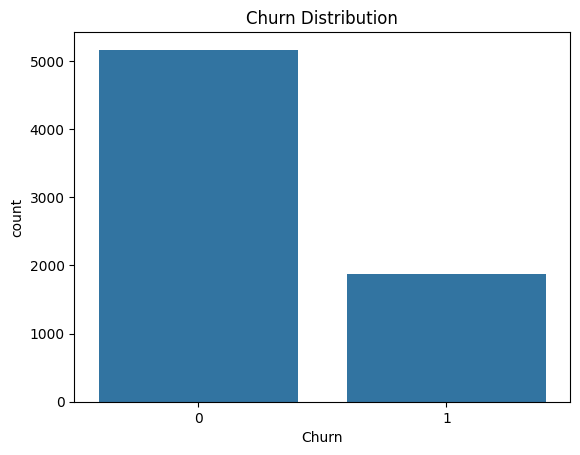

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

**Correlation Heatmap**

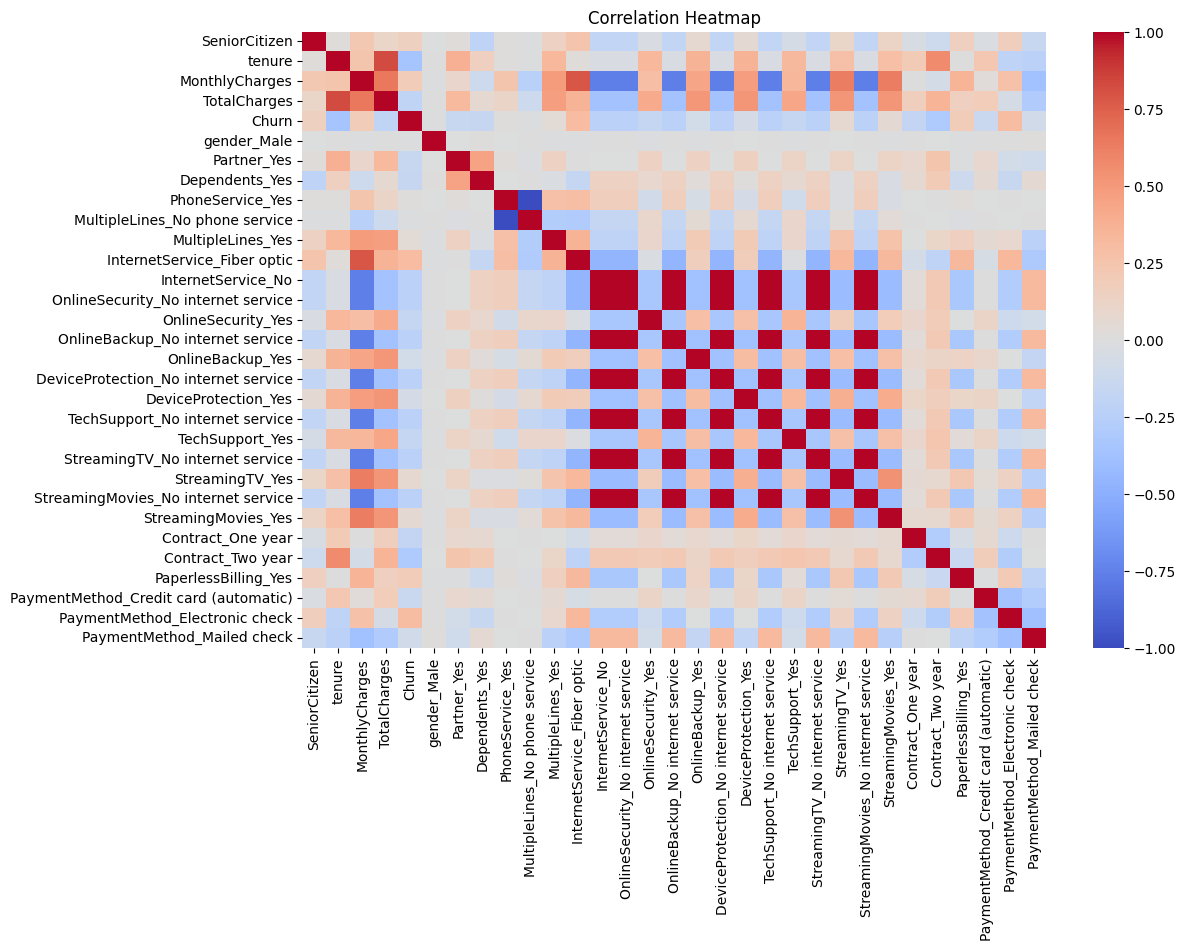

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Step 8: Feature & Target Split

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Step 9: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 0)

print(X_train)
print(X_test)
print(y_train)
print(y_test)

      SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
2964              0      24           58.35       1346.90         True   
5113              0      71          113.65       8166.80        False   
5363              0      70           25.35       1715.15         True   
5074              0      49           19.45        921.30        False   
156               0      22           84.15       1821.95        False   
...             ...     ...             ...           ...          ...   
4939              0       1           18.90         18.90         True   
3269              0      65           24.80       1600.95         True   
1658              0      50          105.95       5341.80         True   
2612              0      14           80.45       1137.05        False   
2737              0      64          104.65       6889.80         True   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
2964         True           False              True   
5

# Step 10: Feature Scaling (for LR & KNN)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled)
print(X_test_scaled)

[[-0.43730142 -0.34083158 -0.21055658 ... -0.52489066  1.39574826
  -0.54276283]
 [-0.43730142  1.57402378  1.63040752 ...  1.90515869 -0.71646158
  -0.54276283]
 [-0.43730142  1.53328218 -1.30914275 ... -0.52489066 -0.71646158
   1.84242537]
 ...
 [-0.43730142  0.71845011  1.37407075 ...  1.90515869 -0.71646158
  -0.54276283]
 [-0.43730142 -0.74824761  0.52516325 ...  1.90515869 -0.71646158
  -0.54276283]
 [-0.43730142  1.28883256  1.33079311 ...  1.90515869 -0.71646158
  -0.54276283]]
[[-0.43730142 -1.27788846 -1.46560805 ... -0.52489066  1.39574826
  -0.54276283]
 [-0.43730142 -0.66676441 -1.46727258 ...  1.90515869 -0.71646158
  -0.54276283]
 [-0.43730142 -1.27788846 -1.49390497 ...  1.90515869 -0.71646158
  -0.54276283]
 ...
 [-0.43730142 -1.11492204  0.16895501 ... -0.52489066  1.39574826
  -0.54276283]
 [-0.43730142  1.28883256  1.67534968 ... -0.52489066  1.39574826
  -0.54276283]
 [ 2.28675226 -0.99269723 -0.70991393 ... -0.52489066 -0.71646158
   1.84242537]]


# Step 11: Model Training

In [ ]:
# 1. Logistic Regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
# 2. KNN

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)


KNeighborsClassifier()

In [ ]:
# 3. Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
# 4. Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)


RandomForestClassifier()

# Step 12: Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Logistic Regression

y_pred_lr = lr.predict(X_test_scaled)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", accuracy_lr)

Accuracy: 0.8073916133617626


In [ ]:
# KNN

y_pred_knn = knn.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", accuracy_knn)

Accuracy: 0.7647476901208244


In [ ]:
# Decision Tree

y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", accuracy_dt)

Accuracy: 0.7313432835820896


In [ ]:
# Random Forest

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy_rf)

Accuracy: 0.7960199004975125


# Step 13: Model Comparison

In [ ]:
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Logistic Regression: 0.8073916133617626
KNN: 0.7647476901208244
Decision Tree: 0.7313432835820896
Random Forest: 0.7960199004975125


# Step 14: Confusion Matrix

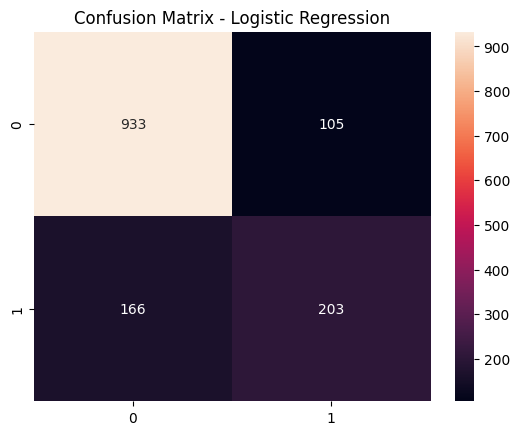

In [111]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Step 15: Feature Importance

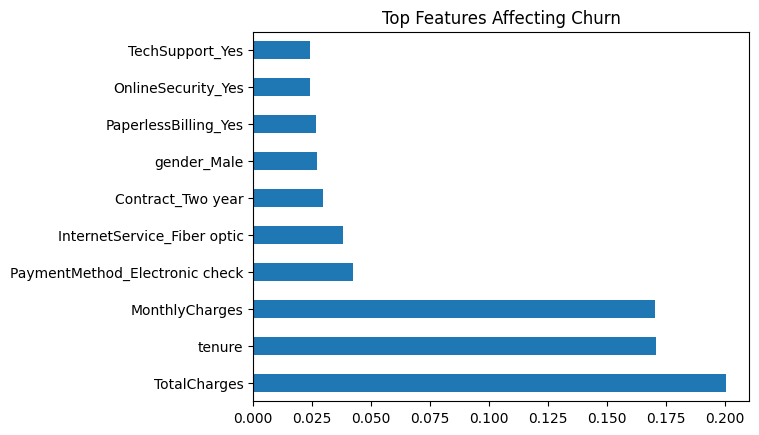

In [ ]:
importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.nlargest(10).plot(kind='barh')
plt.title("Top Features Affecting Churn")
plt.show()

# Step 16: Prediction System

In [ ]:
def predict_churn(input_data):
    import pandas as pd

    # Convert input into DataFrame with correct column names
    input_df = pd.DataFrame([input_data], columns=X.columns)

    # Predict
    prediction = rf.predict(input_df)

    if prediction[0] == 1:
        return "Customer will Churn"
    else:
        return "Customer will Stay"

In [ ]:
sample = X_test.iloc[0]
result = predict_churn(sample)

print(result)

sample1 = X_test.iloc[1]
result1 = predict_churn(sample1)

print(result1)

sample2 = X_test.iloc[697]
result2 = predict_churn(sample2)

print(result2)

Customer will Stay
Customer will Stay
Customer will Stay


In [ ]:
for i in range(150):
    print(f"Customer {i+1}: ", predict_churn(X_test.iloc[i]))

Customer 1:  Customer will Stay
Customer 2:  Customer will Stay
Customer 3:  Customer will Stay
Customer 4:  Customer will Stay
Customer 5:  Customer will Churn
Customer 6:  Customer will Stay
Customer 7:  Customer will Churn
Customer 8:  Customer will Churn
Customer 9:  Customer will Stay
Customer 10:  Customer will Stay
Customer 11:  Customer will Stay
Customer 12:  Customer will Stay
Customer 13:  Customer will Stay
Customer 14:  Customer will Stay
Customer 15:  Customer will Stay
Customer 16:  Customer will Stay
Customer 17:  Customer will Stay
Customer 18:  Customer will Stay
Customer 19:  Customer will Stay
Customer 20:  Customer will Stay
Customer 21:  Customer will Stay
Customer 22:  Customer will Churn
Customer 23:  Customer will Stay
Customer 24:  Customer will Stay
Customer 25:  Customer will Stay
Customer 26:  Customer will Stay
Customer 27:  Customer will Stay
Customer 28:  Customer will Stay
Customer 29:  Customer will Churn
Customer 30:  Customer will Churn
Customer 31: 

**Conclusion:** This project applied machine learning techniques to predict customer churn using a complete data science pipeline, including data preprocessing, analysis, and model training. Multiple models were evaluated, and Logistic Regression achieved the best performance on the dataset. The results show that model effectiveness depends on data characteristics, and simpler models can sometimes outperform complex ones. Overall, the system can help businesses identify potential churn customers and take preventive actions.